# Assignment 2 -  Extended Kalman filter and Unscented Kalman filter


- **Topic:** Desiging an EKF and UKF to estimate the position using magnetic field information
- **Assessment:** The assignment will go through a pass/fail check.


- **Deadline:**  07-03-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment2_groupNumber.ipynb` TO BRIGHTSPACE**, where groupNumber is your groupnumber



## Instructions
**Installation:** The implementation is tested with python 3.9.12 and packages including
-   numpy version: 1.26.4
-   scipy version: 1.13.0
-   matplotlib version: 3.5.1


Other (not too old or new) versions will probabily also work.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.



## AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.


## Information
Please fill in your group number, names and student numbers in the cell below.

<!-- first EKF and then UKF, very similar to normal KF-->

In [17]:
''' YOUR ANSWER HERE '''
groupNumber = 18

STUDENT_1_NAME = "Deepika Phadke"
STUDENT_1_STUDENT_NUMBER = "6250459"

STUDENT_2_NAME = "Abhishek Reddy"
STUDENT_2_STUDENT_NUMBER = "6295142"

# raise NotImplementedError()

## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{p}_t $ of an agent, the same as assignment 1, but using different algorithmns. The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{p}_t $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Where:

- $\mathbf{p}_t$ is a 3-dimensional position vector of the agent at time $t$. 

- $\Delta \mathbf{p}_t$ is the change in positon.

- $\mathbf{w}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{p}_t$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_t$ at every position $\mathbf{p}_t$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

Where:

- $\mathbf{y}_t$ is a 3-dimensional measurement vector of the magnetic field at time-step $t$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times \text{T}}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the EKF and UKF you DO NOT need this dictionary.

In [18]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg

import GP as GP
import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeKalmanFilterAssignment(groupNumber % 29)

Same as the first assignment of particle filter, below, a function `helper.makeDeadReckoningPlots()` is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. You can reuse the code for the plots.

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times \text{T}}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{\text{T}}$.

This function should output two subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

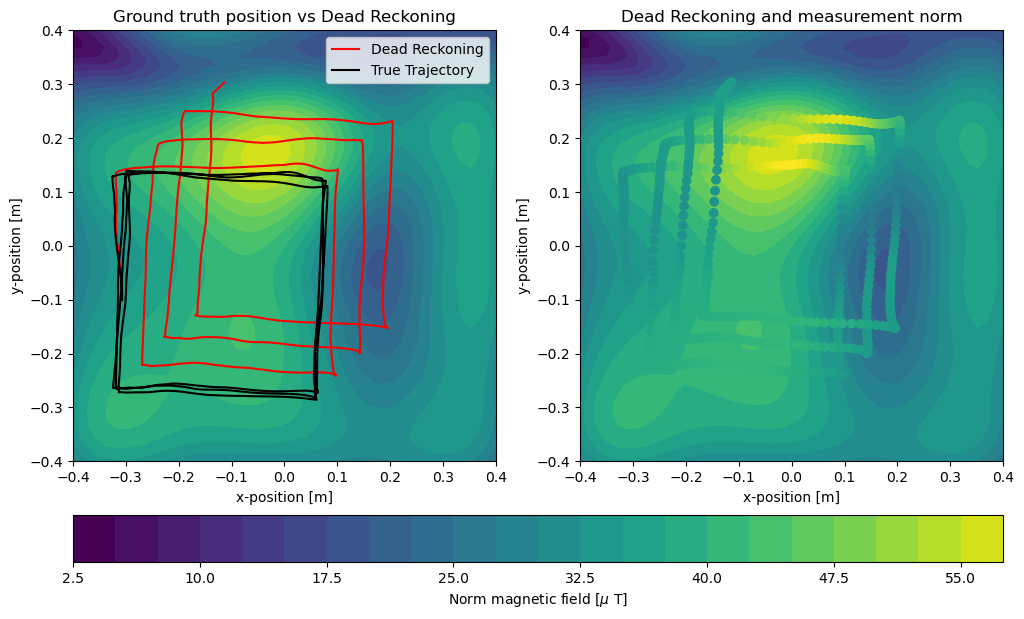

In [19]:
a,N =deltaMagnetometerPositions.shape
deadReckoning = np.zeros((a,N))

deadReckoning[:,0] = magnetometerInitialPosition.T

for i in range(N):
    if i!=0:
        deadReckoning[:,i] = deadReckoning[:,i-1] + deltaMagnetometerPositions[:,i]

magneticFieldNorm = np.linalg.norm(magnetometerMeasurements,axis=0)

helper.makeDeadReckoningPlots(deadReckoning, magneticFieldNorm, modelParameters)

## EKF and UKF
To  use magnetometer measurements to reduce the positional drift observed in the figure above, besides PF in the previous lectures, you can also use EKF and UKF.

### EKF Implementation

You start from implementing EKF.  Your task is to fill in the following functions.

#### Task 1
Fill in the `dynamicUpdateEKF()` function according to the dynamic model given above. 

**Note:**
You do not have to change the inputs and outputs to the given functions.


In [20]:

def dynamicUpdateEKF(position, 
                   deltaPos, 
                   posCov, 
                   motionCovarianceEKF, 
                   modelParameters):
    ''' Dynamic update '''
    position = position + deltaPos  
    m,n = position.shape
    F=np.eye(m)
    posCov = F@posCov@F.T+motionCovarianceEKF

    return position, posCov

#### Task 2

Complete the function `measurementUpdateEKF()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times 1} $. The output should be a matrix $\in \mathbb{R}^{3 \times 1}$ magnetic field predictions for every input location.  Similarly, to find the Jacobian, you muse use the GP.makeMagneticFieldJacobian(position, modelParameters) function make sure the input position is a vector of 3x1. The output should be a matrix of 3x3.

In [21]:
def measurementUpdateEKF(position, 
                         magnetometerMeasurement, 
                         posCov, 
                         measurementCovarianceEKF,
                         modelParameters):
    
    ''' Measurement update '''
    magneticFieldPrediction = GP.makeMagneticFieldPrediction(position, modelParameters) 
    jacobianMagneticFieldPrediction = GP.makeMagneticFieldJacobian(position, modelParameters)

    rk=magnetometerMeasurement-magneticFieldPrediction
    Sk=jacobianMagneticFieldPrediction@posCov@jacobianMagneticFieldPrediction.T+measurementCovarianceEKF
    
    Kk=posCov@jacobianMagneticFieldPrediction.T@np.linalg.inv(Sk)

    position=position+Kk@rk
    posCov=(np.eye(Kk.shape[0],jacobianMagneticFieldPrediction.shape[1])-Kk@jacobianMagneticFieldPrediction)@posCov

    return position, posCov

`extendedKalmanFilter()` is given as follows. You don't need to change it.

In [22]:
''' DO NOT CHANGE THE CODE BELOW '''

def extendedKalmanFilter(position, 
                         deltaPosition, 
                         magnetometerMeasurement, 
                         posCov, 
                         motionCovarianceEKF, 
                         measurementCovarianceEKF, 
                         modelParameters):
    ''' Estimates positions'''

    ''' Dynamic update '''    
    if modelParameters['NtimeStepEKF'] > 0:
        (position, 
         posCov) = dynamicUpdateEKF(position, 
                                  deltaPosition, 
                                  posCov, 
                                  motionCovarianceEKF,
                                  modelParameters)

    ''' Measurement update '''
    (position, 
     posCov) = measurementUpdateEKF(position,
                                    magnetometerMeasurement, 
                                    posCov, 
                                    measurementCovarianceEKF,
                                    modelParameters)

    return position, posCov


#### Task 3

Be sure to set the **initial position** and the **prior** on it correctly  and a **suitable measurement covariance** as you did in assignment 1.

You could start with the following parameters
- `motionCovarianceUKF` = np.eye(3)*0.001**2 
- `measurementCovarianceUKF` = np.eye(3)*1.5**2

Make sure `posCovarianceUKF` is a 3d tensor with the shape of `[3,3,NtimeSteps]`, to save the position covariances for every time step.
To get better results, you might have to tune these. 

In [23]:
''' Initialize the EKF '''
modelParameters['NtimeStepEKF'] = 0

motionCovarianceEKF = np.diag([0.001**2,0.001**2,0.001**2])
measurementCovarianceEKF = np.diag([0.1,3,10]) 

a,N = deltaMagnetometerPositions.shape
posEstEKF = np.zeros((a,modelParameters['NtimeSteps']))
posEstEKF[:,0] = magnetometerInitialPosition.T

posCovarianceEKF = np.zeros((3,3,modelParameters['NtimeSteps']))
posCovarianceEKF[:,:,0] = np.eye(3)*0.001**2
''' Run the EKF'''

for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosEKF = deltaMagnetometerPositions[:, timendx:timendx+1]
    ymeasEKF = magnetometerMeasurements[:, timendx:timendx+1]
    (posEstEKF[:, timendx+1:timendx+2], 
     posCovarianceEKF[:, :, timendx+1]) = extendedKalmanFilter(posEstEKF[:, timendx:timendx+1], 
                                              deltaPosEKF, 
                                              ymeasEKF, 
                                              posCovarianceEKF[:, :, timendx],
                                              motionCovarianceEKF,
                                              measurementCovarianceEKF,
                                              modelParameters)
    modelParameters['NtimeStepEKF'] += 1

#### discussion

Elaborate on the effects of tuning the different variables:

measurementCovarianceEKF = np.diag([0.1,3,10]) 

- `motionCovarianceEKF`: This denotes the confidence we have in our position model. A value of 0.001 applied across the board to x, y and z results in accurate initial position and good tracking of the truth. This is because we are very confident in our dynamic model but not 100% confident. An increased value of covariance (less confidence) results in worse tracking of the truth. A decreased value (more confidence) an accurate first loop but then a distinct drift away similar to the dead-reckoning. It is very sensitive to applying different confidences to x, y and z and gave worse results in these tests, so these were kept the same as each other. 
- `measurementCovarianceEKF`: This denotes the confidence we have in our measurement model. A scaling value of 1.5**2 seems to result in accurate tracking of the true trajectory. Reducing the value results in better tracking of the top left but is otherwise worse. Increasing the value results in better tracking of the bottom right but the left side gets shifted right and away from the truth. This highlights that there is a different effect of x and y measurements on the model. So, we should not tune them to the same value. We can see that the x measurements are more certain than the y measurements, and the z values don't have an effect on the results. This is likely because the robot is always at the same distance away from the ground (it is not changing height). So we apply high confidence (a small number) to the x-related diagonal element, a low confidence (large number) to the y-related element, and a very high value to the z-coordinate information so that it is largely ignored. 
- The initial position covariance `posCovarianceEKF[:, :, 0]`: This denotes the confidence we have in our initial measurement. We know are initial measurement, therefore we should set this to something very close to zero. If we set it to zero it indicates full confidence in this value, and actually makes our position estimates drift a bit away from the truth. So instead we set it very close to zero at 0.001.  


#### Visualize the output
<!-- TODO: keep or not. maybe comparison between EKF and UKF in the end is enough -->

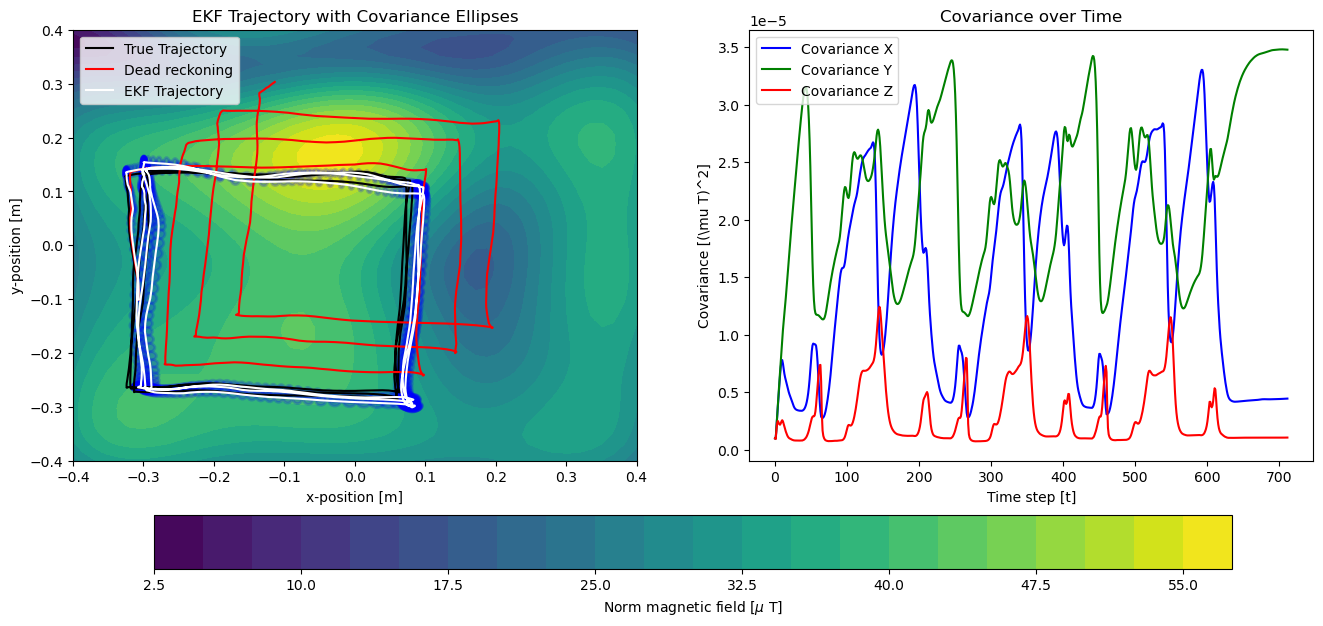

In [24]:
''' DO NOT CHANGE THE CODE BELOW '''
helper.makeExtendedKalmanFilterPlots(deadReckoning, posEstEKF, posCovarianceEKF, modelParameters)

Text(0.5, 0, 'Time Series')

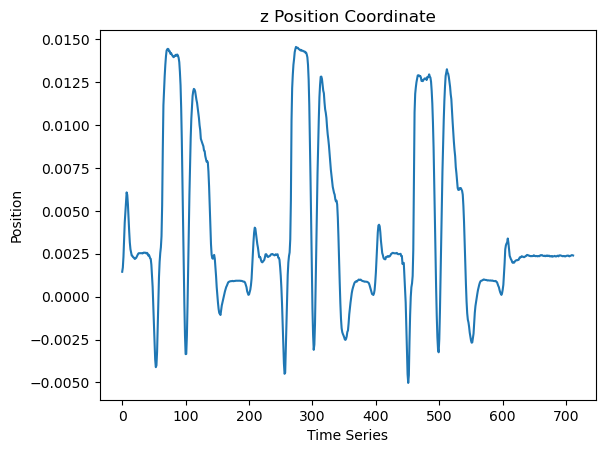

In [25]:
plt.plot(posEstEKF[2,:])
plt.title('z Position Coordinate')
plt.ylabel('Position')
plt.xlabel('Time Series')

**Discussion**

Explain why the covariance changes over time the way it does. You can create more plots if necessary for your analysis.

When the covariance is low, it means the measurements are more sure. "Sure-ity" in measurements is possible when we have variations in the magnetic field as these variations allow us to differentiate points from each other for localization. When we have no variations in the magnetic field, we can't use this method to improve our estimates and so we get higher covariance and less accurate results. The regions of high covariance are cyclic and this likely aligns with a linear region of the trajectory that the sensor passes again and again. In fact this aligns with the increase in the z position (as seen in the above graph). The agent is likely going uphill in these places. It is likely that the magnetic field is measured at a height closer to the rest of the agent trajectory than these higher regions. Therefore in these places the we are less certain of the magnetic field measurement and get higher covariance and worse trajectory tracking. 

### UKF implement 

#### Task 1
Fill in the `dynamicUpdateUKF()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [26]:
def dynamicUpdateUKF(position, 
                   deltaPos, 
                   posCov, 
                   motionCovarianceUKF, 
                   modelParameters):
    ''' Dynamic update '''
    position = position + deltaPos  
    posCov =  posCov + motionCovarianceUKF

    return position, posCov

#### Task 2

- Complete creating sigma points `createSigmaPoints()` and calculating sigma weights `calculateSigmaWeights()`.
- Fill in the `measurementUpdateUKF()` according to the measurement model given above. 
- You can play around with UT1 and UT2, can you see any obvious differences?


In [27]:
def createSigmaPoints(stateVector, 
                      stateCovariance, 
                      lamdaWeights,
                      modelParameters):
    ''' Create sigma points '''
    
    n = int(stateVector.shape[0])  # State dimension
    sqrtMatrix = (scipy.linalg.sqrtm(stateCovariance))

    # Initialise sigma points
    sigmaPoints = np.zeros((n,2*n+1))
    sigmaPoints[:,0] = stateVector.T  # First sigma point (mean state)
    for i in range(n):
        sigmaPoints[:,(i + 1)] = (stateVector.T + np.sqrt(n + lamdaWeights)*sqrtMatrix[:, i])
        sigmaPoints[:,(i + 1 + n)] = (stateVector.T - np.sqrt(n + lamdaWeights)*sqrtMatrix[:, i])
    
    return sigmaPoints


def calculateSigmaWeights(UTnumber = 1):
    ''' Calculate the weights '''
    if UTnumber == 1:
        '''UT1'''
        n=3
        alpha=np.sqrt(3/n)
        kappa=0
        beta=(3/n)-1

    else:
        '''UT2'''
        n=3
        alpha=10**(-3)
        kappa=0
        beta=2
    
    lamdaWeights=(alpha**2)*(n+kappa)-n

    weightsMean = np.zeros(2 * n + 1)
    weightsCov = np.zeros(2 * n + 1)
    weightsMean[0] = lamdaWeights / (n + lamdaWeights)  # 0th weight
    weightsCov[0] = lamdaWeights / (n + lamdaWeights) + (1 - (alpha**2) + beta) # 0th weight
    for i in range(1, 2 * n + 1): # +- i weights
        weightsMean[i] = 1 / (2 * (n + lamdaWeights))
        weightsCov[i] = 1 / (2 * (n + lamdaWeights))


    return lamdaWeights, weightsMean, weightsCov


def measurementUpdateUKF(position,
                         magnetometerMeasurement,
                         posCovariance,
                         measurementCovarianceUKF,
                         lamdaWeights, 
                         weightsMean, 
                         weightsCovariance,
                         modelParameters):
    
    ''' Measurement update '''
    sigmaPoints = createSigmaPoints(position, posCovariance, lamdaWeights, modelParameters)
    
    # Put Sigma Points through Measurement Model
    predictedSigmaPoints = GP.makeMagneticFieldPrediction(sigmaPoints, modelParameters) 

    # Compute predicted measurement mean
    predictedMeasurement = predictedSigmaPoints@weightsMean.T
    predictedMeasurement = predictedMeasurement.reshape((3,1))
    # Compute Sk and Ck
    Sk = measurementCovarianceUKF
    n = position.shape[0]
    Ck = np.zeros((n, n))
    for i in range(int(sigmaPoints.shape[1])):
        diffState = sigmaPoints[:,i].reshape((3,1)) - position.reshape((3,1))
        diffMeasurement = predictedSigmaPoints[:,i].reshape((3,1)) - predictedMeasurement
        Sk = Sk + weightsCovariance[i] * ((diffMeasurement)@(diffMeasurement.T))
        Ck = Ck + weightsCovariance[i] * ((diffState)@(diffMeasurement.T))

    # Kalman Gain
    Kk = Ck @ np.linalg.inv(Sk)

    # Measurement Residual
    rk = magnetometerMeasurement - predictedMeasurement.reshape((3,1))

    # Update state and covariance
    position = position + Kk @ rk
    posCovariance = posCovariance - Kk @ Sk @ Kk.T

    return position, posCovariance

`unscentedKalmanFilter()` is given as follows. You don't need to change it.

In [28]:
''' DO NOT CHANGE THE CODE BELOW '''
def unscentedKalmanFilter(position, 
                          deltaPos, 
                          magnetometerMeasurement, 
                          posCovariance, 
                          motionCovarianceUKF,
                          measurementCovarianceUKF,
                          lamdaWeights, 
                          weightsMean, 
                          weightsCovariance,
                          modelParameters):

    if modelParameters['NtimeStepUKF'] > 0:
        ''' State update '''
        position, posCovariance = dynamicUpdateUKF(position, 
                                                deltaPos, 
                                                posCovariance, 
                                                motionCovarianceUKF, 
                                                modelParameters)

    ''' Measurement update '''
    position, posCovariance = measurementUpdateUKF(position, 
                                                   magnetometerMeasurement, 
                                                   posCovariance, 
                                                   measurementCovarianceUKF,
                                                   lamdaWeights,
                                                   weightsMean,
                                                   weightsCovariance,
                                                   modelParameters)

    return position, posCovariance



#### Task 3

Be sure to set the **initial position** and the **prior** on it correctly  and a **suitable measurement covariance** as you did in assignment 1.

You could start with the following parameters
- `motionCovarianceUKF` = np.eye(3)*0.001**2 
- `measurementCovarianceUKF` = np.eye(3)*1.5**2

Make sure `posCovarianceUKF` is a 3d tensor with the shape of `[3,3,NtimeSteps]`, to save the position covariances for every time step.
To get better results, you might have to tune these. 

In [29]:

''' Initialize the UKF '''
modelParameters['NtimeStepUKF'] = 0

motionCovarianceUKF = np.diag([0.001**2,0.001**2,0.001**2])
measurementCovarianceUKF = np.diag([0.1,3,10]) 

posEstUKF = np.zeros((3,modelParameters['NtimeSteps']))
posCovarianceUKF = np.zeros((3,3,modelParameters['NtimeSteps']))

posEstUKF[:,0] = magnetometerInitialPosition.T 
posCovarianceUKF[:,:,0] = np.eye(3)*0.001**2 # we are very sure of the initial position so we should set this. 



lamdaWeights, weightsMean, weightsCovariance = calculateSigmaWeights()
''' Run the UKF'''
for timendx in range(modelParameters['NtimeSteps']-1):
    (posEstUKF[:, timendx+1:timendx+2], 
     posCovarianceUKF[:, :, timendx+1]) = unscentedKalmanFilter(posEstUKF[:, timendx:timendx+1], 
                                               deltaMagnetometerPositions[:, timendx:timendx+1], 
                                               magnetometerMeasurements[:, timendx:timendx+1], 
                                               posCovarianceUKF[:, :, timendx],
                                               motionCovarianceUKF,
                                               measurementCovarianceUKF,
                                               lamdaWeights, 
                                               weightsMean, 
                                               weightsCovariance,
                                               modelParameters)
    modelParameters['NtimeStepUKF'] += 1



posCovarianceEKF = np.zeros((3, 3, modelParameters['NtimeSteps']))
posCovarianceEKF[:,:,0] = np.eye(3)*0.001


#### discussion

Elaborate on the effects of tuning the different variables:

- `motionCovarianceUKF` : This is used to determine our confidence in the dynamics of our model. For simplicity, we have assumed no cross-correlation between the three co-ordinate directions (however, practically this does exist but is pretty small). We have tuned this by changing the values of the auto-correlation of x, y and z in the position. Keeping the other covariances constant and varying them one by one, we see that by increasing the auto-correlation, for example, x-direction, leads to the filter being more unsure about the dynamics in the x-axis, causing sub-par estimates. However, it we were to decrease the motion covariance, the estimate drifts to the dead reckoning.
- `measurementCovarianceUKF` : This is used to determine our confidence in the measurement of the magnetometer. Similar to the motion covariance, we can split this into the magnetic strength for each corresponding cardinal direction. Varying each direction's auto-correlation either relaxes or contricts reliability of that direction's magnetometer measurement. Similar to the discussion of EKF, varying x and y directions do not effect the results as much as losing confidence in the z-direction does. This tells us that the predicted magnetic field (using the given function), works pretty well in the x direction but performs relatively poorly in the y-z plane which is why we increase the convariance in this direction.  
- The initial posiiton covariance `posCovarianceUKF[:, :, 0]` : This denotes the confidence we have in our initial measurement. We know are initial measurement, therefore we should set this to something very close to zero. If we set it to zero it indicates full confidence in this value, and actually makes our position estimates drift a bit away from the truth. So instead we set it very close to zero at 0.001.

Is it different from tuning the variables for the EKF?
- For this particular example, the tuning of EKF and UKF are largely similar.

### compare EKF and UKF
#### Visualize the output

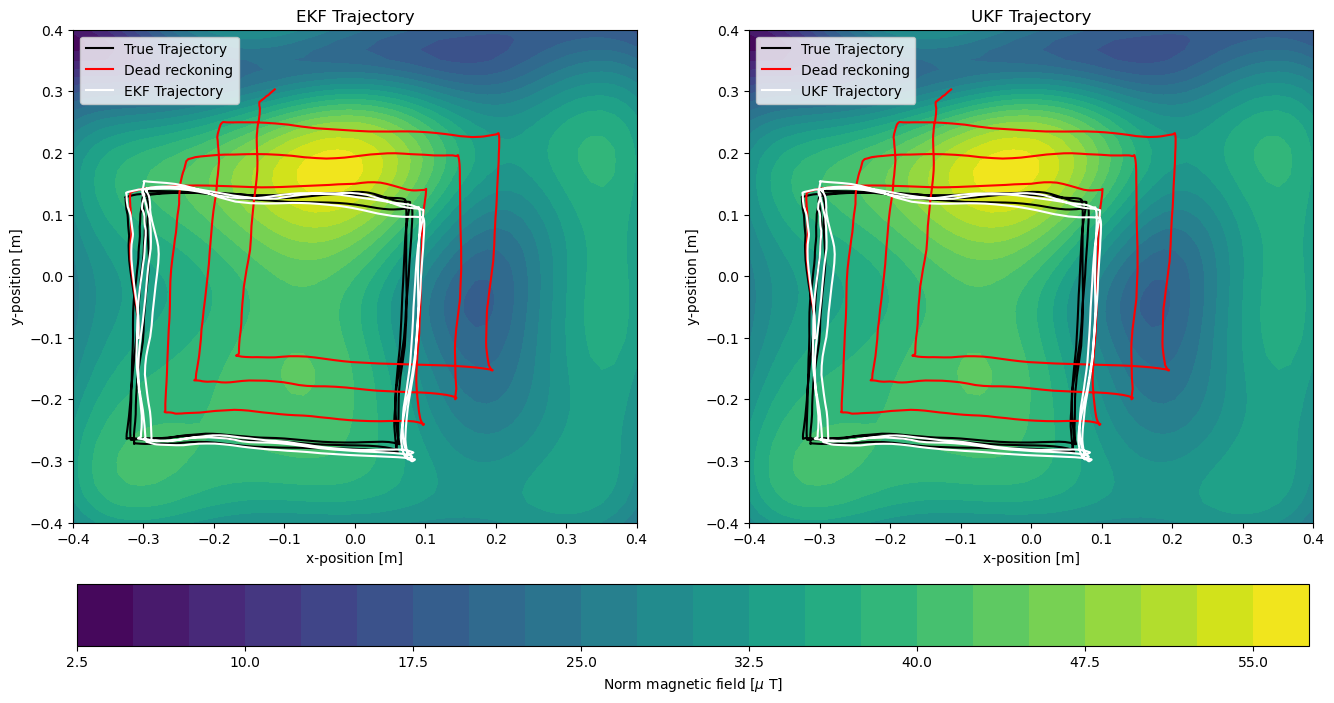

In [30]:
helper.makeKalmanFilterPlots(deadReckoning, posEstEKF, posEstUKF, modelParameters)

#### Discussion
Elaborate on the two plots.
- Compare the results from the UKF with the EKF? Does one provide better results? Elaborate!

The results of the UKF and EKF are almost exactly the same apart from very tiny variations. This is expected since the dynamic model is linear, there is no effect of using a UKF filter for the dynamic update. However, after playing around with UT1 and UT2, we have observed that they yield similar results as well. This tells us that the unlying non-linearity is not highly non-linear. Because of this, linearizing it and using it in EKF or even accepting the non-linearity and using in UKF have yielded the same results. 

- Comment on the reason for choosing either EKF, UKF or PF for this non-linear estimation problem. Also relate this to the results from assignment 1. 

EKF would be the best for this particular non-linear estimation problem since after comparing the results with the UKF model, we have seen that they yield pretty much the same results. Since we have an indication that the measurement model is not as non-linear as we had assumed (also, UT1 which is a first order approximation and UT2 which is a second order approximation give similar results), we can approximate it with a linear model (using the jacobian) and proceeding with EKF. EKF also has the edge over particle filtering sheerly in terms of the computation time and power, and still gives use similar results. EKF is also ever so slightly faster than UKF in this case as well (0.2s for EKF and 0.7s for UKF, which is pretty much negligible).

- In what type of estimation problems would you expect to see very different results for the EKF, UKF and PF? 

For a highly non-linear problem (non-linear dynamics and measurement models) with non-gaussian uncertainities would yield very different results for EKF, UKF and PF. UKF would perform much better than EKF in this scenario since a linear approximation of the model would give us poor results. PF would probably have the edge for non-gaussian uncertainities.


<!-- TODO: DO WE NEED THE "PLAY AROUND WITH DIFFERENT PARAMETERS SESSION AS THE FIRST ASSIGMENT?" -->